<a href="https://colab.research.google.com/github/ac5589/Pytorch-tutorial-Youtube/blob/main/Basic_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import all the necessary libraries
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Create the Model class that inherits nn.Module
class Model(nn.Module):
  # Input layer ( 4 features of the flower)
  # Hidden Layer1 (number of neurons) H1
  # Hiden Layer2 (number of neurons) H2
  # output ( 3 classes of the flower)

  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__() # instantiate our nn.module
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)
    return x


In [3]:
# Pick a manual seed for randomization
torch.manual_seed(41)

# Create an instance of the model
model = Model()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
# Load the data from the weblink
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [6]:
my_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [7]:
my_df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


In [8]:
# Change the last column from strings to numbers.
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

/tmp/ipykernel_1786/419654766.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


In [9]:
my_df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0
149,5.9,3.0,5.1,1.8,2.0


In [10]:
# Train, Test split
X = my_df.drop('variety', axis=1)
y = my_df['variety']
X.head()

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [11]:
# Convert X and y to numpy arrays
X = X.values
y = y.values

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [14]:
# Convert the features into tensor
X_train = torch.FloatTensor(X_train)
X_test  = torch.FloatTensor(X_test)

In [15]:
# Convert the y labels into long tensor
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [16]:
# Set the criteria for the model to measure the error
criterion = nn.CrossEntropyLoss()

# Choose an optimizer and the learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [17]:
# Train our model

# Number of Epochs
epoch = 100

losses = []

for i in range(epoch):
  # Prediction
  y_pred = model.forward(X_train) # Get prdicted results

  # Measure the loss/error
  loss = criterion(y_pred, y_train)

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # Print every 10 epochs
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do back propagation
  # You take the error rate for the forward propagation and feed it back to the network to fine tune the weight.
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.125203251838684
Epoch: 10 and loss: 1.0097211599349976
Epoch: 20 and loss: 0.8162348866462708
Epoch: 30 and loss: 0.585993230342865
Epoch: 40 and loss: 0.4003390073776245
Epoch: 50 and loss: 0.2679471969604492
Epoch: 60 and loss: 0.1796349734067917
Epoch: 70 and loss: 0.12165623158216476
Epoch: 80 and loss: 0.0860651433467865
Epoch: 90 and loss: 0.06522615998983383


Text(0.5, 0, 'Epoch')

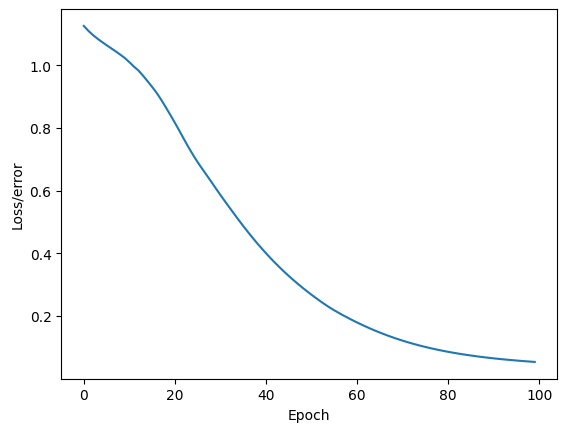

In [18]:
# Graph the loss
plt.plot(range(epoch), losses)
plt.ylabel('Loss/error')
plt.xlabel('Epoch')

In [20]:
# Validate the model on th test dataset
with torch.no_grad(): # turn off the back propagation
  y_eval = model.forward(X_test) # X_test are the features from the test set, y_eval is the prediction
  loss = criterion(y_eval, y_test)

loss

tensor(0.1315)

In [44]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = "Setosa"
    elif y_test[i] == 1:
      x = "Versicolor"
    elif y_test[i] == 2:
      x = "Virginica"

    # Print the label
    print(f'{i+1} {str(y_val)} \t True label: {x}, \t Estimated label: {y_val.argmax().item()}')

    # correct or not
    if y_val.argmax().item() == y_test[i]:
      correct += 1

print(f'We are {correct/y_test.size(dim=0) * 100} % correct')

1 tensor([-5.8771,  4.4629,  6.5155]) 	 True label: Virginica, 	 Estimated label: 2
2 tensor([-7.5451,  4.1668,  9.7293]) 	 True label: Virginica, 	 Estimated label: 2
3 tensor([-8.4517,  5.1275, 10.2015]) 	 True label: Virginica, 	 Estimated label: 2
4 tensor([-4.3411,  5.6280,  2.5636]) 	 True label: Versicolor, 	 Estimated label: 1
5 tensor([-7.1838,  4.8757,  8.3024]) 	 True label: Virginica, 	 Estimated label: 2
6 tensor([-3.3940,  5.3421,  1.2802]) 	 True label: Versicolor, 	 Estimated label: 1
7 tensor([-5.9240,  4.9826,  6.0025]) 	 True label: Virginica, 	 Estimated label: 2
8 tensor([-4.2895,  5.7016,  2.3920]) 	 True label: Versicolor, 	 Estimated label: 1
9 tensor([-6.5369,  4.9261,  7.1291]) 	 True label: Virginica, 	 Estimated label: 2
10 tensor([-8.0526,  4.4129, 10.3325]) 	 True label: Virginica, 	 Estimated label: 2
11 tensor([-5.6775,  4.9505,  5.6248]) 	 True label: Virginica, 	 Estimated label: 2
12 tensor([ 4.5748, -2.2579, -2.8925]) 	 True label: Setosa, 	 Estimate

In [41]:
y_test.size(dim=0)

30